<a href="https://colab.research.google.com/github/hari-dev-05/checking_ML/blob/main/hosuepricepred.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!git clone https://github.com/fourstepsproducts/data_set-.git

Cloning into 'data_set-'...
remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 9 (delta 1), reused 5 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (9/9), 4.93 KiB | 4.93 MiB/s, done.
Resolving deltas: 100% (1/1), done.


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import linear_model
from sklearn.linear_model import LinearRegression

# Matplotlib is a Python plotting/visualization library.
# Seaborn is also a Python visualization library, mainly designed for statistical and data-analysis graphs.

# reading the dataset
house = pd.read_csv("data_set-/House_Price_Prediction_125_Rows.csv")

In [6]:
house.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     125 non-null    int64  
 1   price                  125 non-null    int64  
 2   bedrooms               125 non-null    int64  
 3   location               125 non-null    object 
 4   size_cent              125 non-null    int64  
 5   age_of_house           125 non-null    int64  
 6   parking                125 non-null    object 
 7   floor                  125 non-null    object 
 8   distance_to_main_road  125 non-null    float64
dtypes: float64(1), int64(5), object(3)
memory usage: 8.9+ KB


In [7]:
house.head()

,id,price,bedrooms,location,size_cent,age_of_house,parking,floor,distance_to_main_road
0,1,10032363,2,City,5,1,Yes,First,0.3
1,2,8238171,3,City,2,4,No,First,0.2
2,3,7614478,3,Outer,2,1,No,First,0.3
3,4,7657451,2,City,2,1,Yes,Second,0.9
4,5,7449012,1,City,2,1,No,Ground,0.4


In [8]:
# location: City or Outer
house['location'].astype('category').value_counts()

,count
location,
City,77
Outer,48


In [9]:
# floor: Ground, First or Second
house['floor'].astype('category').value_counts()

,count
floor,
First,54
Ground,41
Second,30


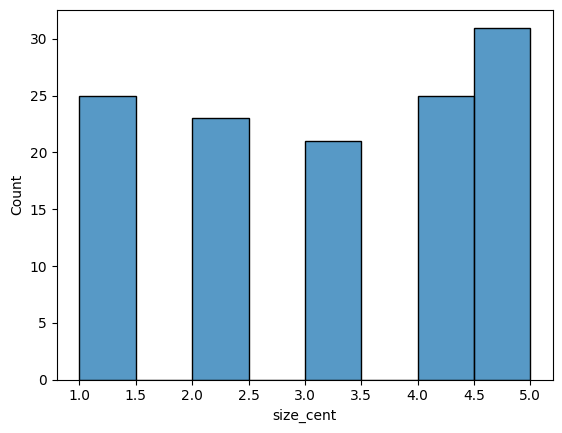

In [10]:
# size_cent: size of the house in cents
sns.histplot(house['size_cent'])
plt.show()

/tmp/ipykernel_2013/1323744728.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(house['age_of_house'])


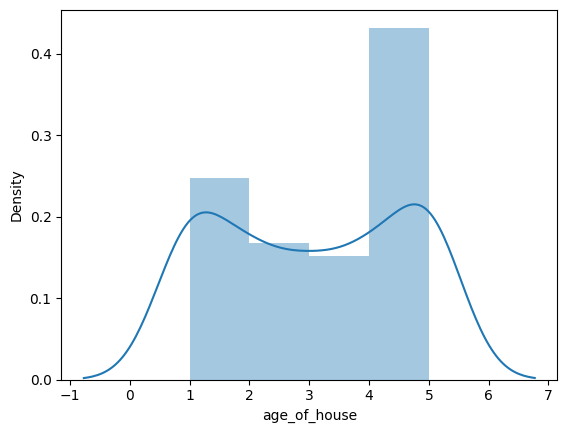

In [11]:
# age_of_house: 1 = newer house, 5 = older house
sns.distplot(house['age_of_house'])
plt.show()

In [12]:
house_numeric = house.select_dtypes(include=['float64', 'int'])
house_numeric.head()

,id,price,bedrooms,size_cent,age_of_house,distance_to_main_road
0,1,10032363,2,5,1,0.3
1,2,8238171,3,2,4,0.2
2,3,7614478,3,2,1,0.3
3,4,7657451,2,2,1,0.9
4,5,7449012,1,2,1,0.4


In [13]:
# dropping id
house_numeric = house_numeric.drop(['id'], axis=1)
house_numeric.head()

,price,bedrooms,size_cent,age_of_house,distance_to_main_road
0,10032363,2,5,1,0.3
1,8238171,3,2,4,0.2
2,7614478,3,2,1,0.3
3,7657451,2,2,1,0.9
4,7449012,1,2,1,0.4


In [14]:
cor = house_numeric.corr()
cor

,price,bedrooms,size_cent,age_of_house,distance_to_main_road
price,1.000000,0.414519,0.718534,-0.047559,-0.104756
bedrooms,0.414519,1.000000,-0.057377,0.119233,0.102195
size_cent,0.718534,-0.057377,1.000000,0.107645,-0.005088
age_of_house,-0.047559,0.119233,0.107645,1.000000,0.073762
distance_to_main_road,-0.104756,0.102195,-0.005088,0.073762,1.000000


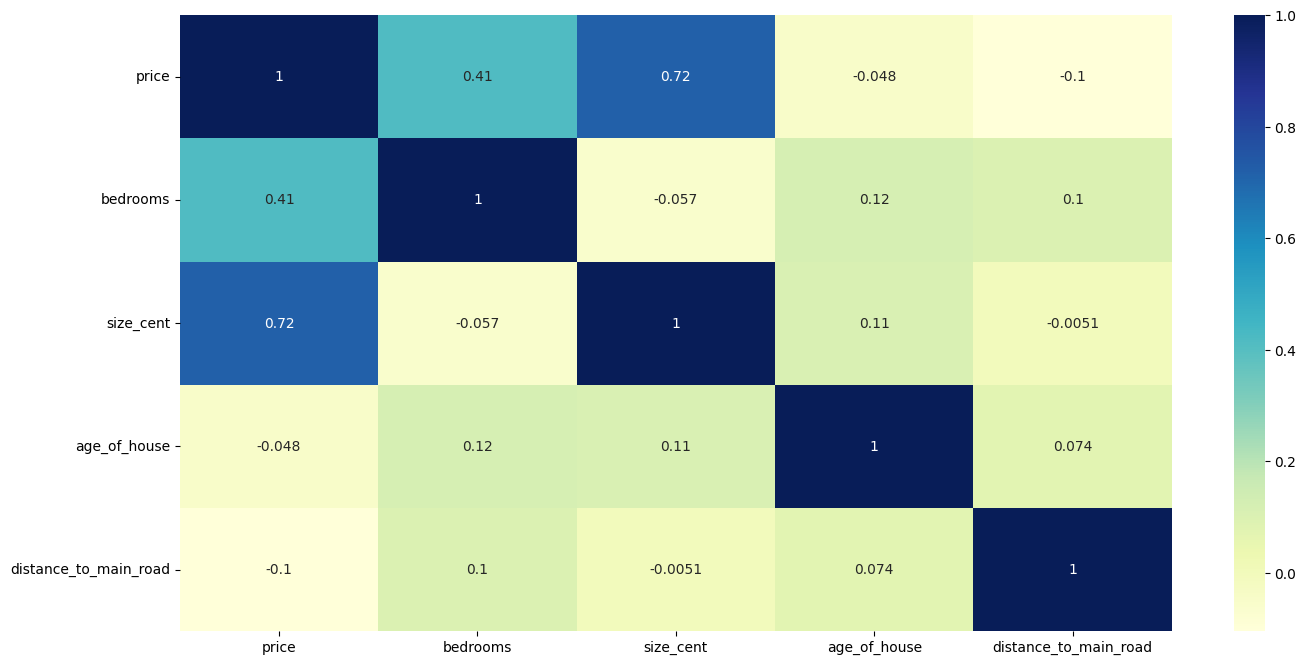

In [15]:
# plotting correlations on a heatmap

plt.figure(figsize=(16, 8))

sns.heatmap(cor, cmap="YlGnBu", annot=True)
plt.show()

In [16]:
# variable formats
house.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     125 non-null    int64  
 1   price                  125 non-null    int64  
 2   bedrooms               125 non-null    int64  
 3   location               125 non-null    object 
 4   size_cent              125 non-null    int64  
 5   age_of_house           125 non-null    int64  
 6   parking                125 non-null    object 
 7   floor                  125 non-null    object 
 8   distance_to_main_road  125 non-null    float64
dtypes: float64(1), int64(5), object(3)
memory usage: 8.9+ KB


In [17]:
house_categorical = house.select_dtypes(include=['object'])
house_categorical.head()

,location,parking,floor
0,City,Yes,First
1,City,No,First
2,Outer,No,First
3,City,Yes,Second
4,City,No,Ground


In [18]:
# creating dummy variables for categorical variables
house_dummies = pd.get_dummies(house_categorical, drop_first=True)

house_dummies.head()

,location_Outer,parking_Yes,floor_Ground,floor_Second
0,False,True,False,False
1,False,False,False,False
2,True,False,False,False
3,False,True,False,True
4,False,False,True,False


In [19]:
# drop categorical variables
X = house_numeric.drop(['price'], axis=1)

X.head()

,bedrooms,size_cent,age_of_house,distance_to_main_road
0,2,5,1,0.3
1,3,2,4,0.2
2,3,2,1,0.3
3,2,2,1,0.9
4,1,2,1,0.4


In [20]:
# concat dummy variables with X
X = pd.concat([X, house_dummies], axis=1)

X.head()

,bedrooms,size_cent,age_of_house,distance_to_main_road,location_Outer,parking_Yes,floor_Ground,floor_Second
0,2,5,1,0.3,False,True,False,False
1,3,2,4,0.2,False,False,False,False
2,3,2,1,0.3,True,False,False,False
3,2,2,1,0.9,False,True,False,True
4,1,2,1,0.4,False,False,True,False


In [21]:
# check the data types
X.dtypes

,0
bedrooms,int64
size_cent,int64
age_of_house,int64
distance_to_main_road,float64
location_Outer,bool
parking_Yes,bool
floor_Ground,bool
floor_Second,bool


In [23]:
columns = X.columns

columns

Index(['bedrooms', 'size_cent', 'age_of_house', 'distance_to_main_road',
       'location_Outer', 'parking_Yes', 'floor_Ground', 'floor_Second'],
      dtype='object')

In [27]:
from sklearn.preprocessing import scale
X = pd.DataFrame(scale(X))
X

,0,1,2,3,4,5,6,7
0,-0.020524,1.283595,-1.316327,-1.110846,-0.789542,0.685994,-0.698638,-0.561951
1,1.262219,-0.756016,0.627069,-1.516857,-0.789542,-1.457738,-0.698638,-0.561951
2,1.262219,-0.756016,-1.316327,-1.110846,1.266557,-1.457738,-0.698638,-0.561951
3,-0.020524,-0.756016,-1.316327,1.325220,-0.789542,0.685994,-0.698638,1.779513
4,-1.303267,-0.756016,-1.316327,-0.704835,-0.789542,-1.457738,1.431356,-0.561951
...,...,...,...,...,...,...,...,...
120,1.262219,-1.435886,-0.020730,-1.110846,-0.789542,0.685994,1.431356,-0.561951
121,1.262219,-1.435886,-1.316327,0.513198,-0.789542,-1.457738,1.431356,-0.561951
122,-0.020524,-0.076145,-1.316327,-0.298824,-0.789542,0.685994,-0.698638,1.779513
123,-1.303267,1.283595,1.274868,-1.516857,1.266557,-1.457738,-0.698638,1.779513


In [29]:
X.columns = columns
X

,bedrooms,size_cent,age_of_house,distance_to_main_road,location_Outer,parking_Yes,floor_Ground,floor_Second
0,-0.020524,1.283595,-1.316327,-1.110846,-0.789542,0.685994,-0.698638,-0.561951
1,1.262219,-0.756016,0.627069,-1.516857,-0.789542,-1.457738,-0.698638,-0.561951
2,1.262219,-0.756016,-1.316327,-1.110846,1.266557,-1.457738,-0.698638,-0.561951
3,-0.020524,-0.756016,-1.316327,1.325220,-0.789542,0.685994,-0.698638,1.779513
4,-1.303267,-0.756016,-1.316327,-0.704835,-0.789542,-1.457738,1.431356,-0.561951
...,...,...,...,...,...,...,...,...
120,1.262219,-1.435886,-0.020730,-1.110846,-0.789542,0.685994,1.431356,-0.561951
121,1.262219,-1.435886,-1.316327,0.513198,-0.789542,-1.457738,1.431356,-0.561951
122,-0.020524,-0.076145,-1.316327,-0.298824,-0.789542,0.685994,-0.698638,1.779513
123,-1.303267,1.283595,1.274868,-1.516857,1.266557,-1.457738,-0.698638,1.779513


In [30]:
y = house['price']

In [31]:
# split into train and test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    train_size=0.7,
    test_size=0.3,
    random_state=100
)

In [32]:
# instantiate
lm = LinearRegression()

# fit the model
lm.fit(X_train, y_train)

LinearRegression()

In [34]:
# predictions on the test set
y_pred = lm.predict(X_test)
y_pred

array([8396268.26592623, 6142585.58151678, 7954963.54140191,
       8926686.74149258, 7645449.90606798, 7734812.80123681,
       6831537.46941375, 7949037.43233254, 8017835.02176476,
       6516987.77761007, 6963146.77613457, 9109282.4435756 ,
       8760681.15913803, 8141594.19256731, 7014771.71360116,
       9956949.46271313, 7081104.94474948, 6070810.68182387,
       6535926.06664836, 8183840.6041193 , 6163387.59934013,
       8114195.25891117, 8741989.9963768 , 7512112.87488004,
       8637835.96861804, 8507769.35682718, 6728468.71122953,
       8791863.41242433, 7328878.63069262, 9686565.77330655,
       8582716.53246108, 9238888.26398644, 7665445.91452186,
       6319278.77193146, 8799363.82717798, 7261278.51820092,
       7920814.39204524, 8182992.84834339])

In [36]:
from sklearn.metrics import r2_score

r2_score(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model Accuracy:", r2 * 100, "%")

Model Accuracy: 98.61122292713205 %
